# Flight Delay Training Pipeline Walkthrough

This notebook shows the training pipeline step by step. It is meant for team members who want to understand what happens without reading all Python modules first.

Goal: classify the departure delay into four classes two hours before departure:

- `no_delay`: delay <= 15 minutes
- `small_delay`: 15 minutes < delay <= 1 hour
- `medium_delay`: 1 hour < delay <= 3 hours
- `large_delay`: delay > 3 hours


## 1. Setup

Run this notebook from the `pipeline/` folder.

In Colab, mount Drive and set `DATA_ROOT` below. If imports fail in Colab, install the needed packages once:

```python
%pip install pandas numpy scikit-learn pyarrow s3fs joblib
```


In [21]:
from pathlib import Path
import os
import sys
import importlib
import pandas as pd
from dotenv import load_dotenv

# Make local imports work when the notebook is opened from another folder.
PIPELINE_DIR = Path.cwd()
if not (PIPELINE_DIR / 'loader.py').exists():
    PIPELINE_DIR = Path.cwd() / 'pipeline'

if str(PIPELINE_DIR) not in sys.path:
    sys.path.append(str(PIPELINE_DIR))

from loader import LoaderStorage
from targets import add_delay_class_target, DELAY_CLASS_ORDER
from split import chronological_train_val_test_split
from features import build_feature_matrix, fit_transform, transform, check_columns
from evaluate import evaluate_classifier, classification_report_frame, f1_macro_score, plotConfusionMatrix
from train import TrainingConfig, run_training
import models
importlib.reload(models)
from models import make_model,make_neural_network_model, get_feature_importances, plot_feature_importances


In [22]:
from models import make_model,make_neural_network_model, get_feature_importances, plot_feature_importances


## 2. Configuration

Only change this cell for normal usage.

Examples:

- Colab/Drive: `DATA_ROOT = "/content/drive/MyDrive/Datamining"`
- S3: `DATA_ROOT = "s3://data-mining"`
- Local folder: `DATA_ROOT = "."`


In [23]:
# Change these paths to your actual dataset location.
DATA_ROOT = "s3://data-mining"
INPUT_PATH = 'data/features/feature_engineered.parquet'

# Column names used by the current pipeline.
DELAY_COLUMN = 'ArrDelayMinutes'
TIME_COLUMN = 'CRSDepDateTime_UTC'
TARGET_COLUMN = 'delay_class'

# Use a small sample while learning/debugging. Set to 1.0 for the final run.
SAMPLE_FRAC = 1.0

# Good first choices: 'dummy', 'logistic_regression', 'random_forest', 'hist_gradient_boosting', xgboost.
MODEL_NAME = 'xgboost'

OUTPUT_DIR = 'outputs/training_notebook'


## 3. Load The Data

`LoaderStorage` hides whether the file is loaded from local disk, Google Drive, or S3. The rest of the notebook can use the same code for all three.


In [24]:
storage = LoaderStorage(DATA_ROOT)

if INPUT_PATH.endswith('.parquet'):
    df = storage.read_parquet(INPUT_PATH)
elif INPUT_PATH.endswith('.csv'):
    df = storage.read_csv(INPUT_PATH)
else:
    raise ValueError('Use a .parquet or .csv dataset.')

if SAMPLE_FRAC < 1.0:
    df = df.sample(frac=SAMPLE_FRAC, random_state=42)

print(f'Rows: {len(df):,}')
print(f'Columns: {len(df.columns):,}')
df.head()


Rows: 4,042,789
Columns: 68


,Unnamed: 0,Year,Month,DayofMonth,DayOfWeek,Reporting_Airline,Origin,Dest,ArrDelayMinutes,CRSElapsedTime,...,hist_dest_delay_7d,hist_dest_delay_30d,origin_yesterday_delay,origin_lastweek_delay,dest_yesterday_delay,dest_lastweek_delay,airline_yesterday_delay,airline_lastweek_delay,global_yesterday_delay,global_lastweek_delay
0,425849,2014,1,1,3,DL,PHX,DTW,0.0,218.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,428286,2014,1,1,3,DL,SLC,ATL,0.0,207.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,407750,2014,1,1,3,B6,DEN,JFK,0.0,212.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,429330,2014,1,1,3,DL,DEN,ATL,0.0,158.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,366498,2014,1,1,3,AA,SFO,DFW,2.0,195.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 4. Create The Target Classes

The raw delay in minutes is converted into the four interval classes. After this step, the model predicts `delay_class`, not the exact number of minutes.


In [25]:
df = add_delay_class_target(
    df,
    delay_column=DELAY_COLUMN,
    target_column=TARGET_COLUMN,
)

# Show the class balance. This is important because large delays are usually rare.
class_distribution = (
    df[TARGET_COLUMN]
    .value_counts()
    .reindex(DELAY_CLASS_ORDER, fill_value=0)
    .to_frame(name='count')
)

class_distribution['share'] = class_distribution['count'] / len(df)
# expected amount in the test set (20% of the data)
class_distribution['expected_in_test'] = class_distribution['count'] * 0.15
display(class_distribution)

,count,share,expected_in_test
delay_class,,,
no_delay,3239932,0.801410,485989.80
small_delay,562651,0.139174,84397.65
medium_delay,205790,0.050903,30868.50
large_delay,34416,0.008513,5162.40


In [26]:
# display all the records, that are in the Large delay class
display(df[df["delay_class"] == 'large_delay'])

,Unnamed: 0,Year,Month,DayofMonth,DayOfWeek,Reporting_Airline,Origin,Dest,ArrDelayMinutes,CRSElapsedTime,...,hist_dest_delay_30d,origin_yesterday_delay,origin_lastweek_delay,dest_yesterday_delay,dest_lastweek_delay,airline_yesterday_delay,airline_lastweek_delay,global_yesterday_delay,global_lastweek_delay,delay_class
537,336465,2014,1,1,3,UA,ORD,IAH,299.0,173.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,large_delay
632,334304,2014,1,1,3,UA,LAS,ORD,541.0,217.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,large_delay
1101,428136,2014,1,1,3,DL,MDW,ATL,219.0,107.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,large_delay
1106,334046,2014,1,1,3,UA,ORD,HNL,201.0,551.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,large_delay
1195,389941,2014,1,1,3,AA,ORD,DFW,325.0,150.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,large_delay
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4041103,107858,2015,12,31,4,B6,BOS,BWI,223.0,96.0,...,11.522342,33.492754,15.614458,40.007092,20.791304,33.089636,20.533333,29.68104,23.270822,large_delay
4041461,8586,2015,12,31,4,AA,ORD,MIA,252.0,189.0,...,16.023418,33.097315,15.587786,22.435484,27.129944,20.756787,12.052469,29.68104,23.270822,large_delay
4041507,416059,2015,12,31,4,DL,HOU,ATL,301.0,122.0,...,15.595643,35.650485,16.986842,56.397647,106.568966,33.726346,66.428122,29.68104,23.270822,large_delay
4041855,107859,2015,12,31,4,B6,BWI,BOS,211.0,80.0,...,14.359698,42.468085,37.623932,25.165877,13.777778,33.089636,20.533333,29.68104,23.270822,large_delay


In [27]:
# check if all expected Columsn are present, and what unexpected ones we have.
# drop the Unnamed:0 column
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
check_columns(df)


Info: The following columns are in the dataset but not recorded in the feature engineering lists: {'CRSDepDateTime_UTC'}


## 5. Chronological Train / Validation / Test Split

For a forecasting-like task, we should not randomly mix old and future flights. The model trains on older flights and is evaluated on later flights.

- Train: first 70% of time
- Validation: next 15%
- Test: final 15%


In [28]:
train_df, val_df, test_df = chronological_train_val_test_split(
    df,
    time_column=TIME_COLUMN,
)

print(f'Train rows:      {len(train_df):,}')
print(f'Validation rows: {len(val_df):,}')
print(f'Test rows:       {len(test_df):,}')

pd.DataFrame({
    'split': ['train', 'validation', 'test'],
    'start': [train_df[TIME_COLUMN].min(), val_df[TIME_COLUMN].min(), test_df[TIME_COLUMN].min()],
    'end': [train_df[TIME_COLUMN].max(), val_df[TIME_COLUMN].max(), test_df[TIME_COLUMN].max()],
    'rows': [len(train_df), len(val_df), len(test_df)],
})
# drop the time column to avoid data leakage. We will use it later to check the chronological order of the splits.
train_df = train_df.drop(columns=[TIME_COLUMN])
val_df = val_df.drop(columns=[TIME_COLUMN])
test_df = test_df.drop(columns=[TIME_COLUMN])

Train rows:      2,829,952
Validation rows: 606,418
Test rows:       606,419


## 6. Build Features

This step separates `X` and `y`:

- `X`: the input columns the model is allowed to use
- `y`: the delay class the model should learn to predict

The helper also drops obvious leakage columns like actual delay, actual departure time, actual arrival time, etc.


In [29]:
X_train, y_train = fit_transform(train_df, scale="minmax") # alternatively "standard"
X_val, y_val = transform(val_df)
X_test, y_test = transform(test_df)



print(f'Number of model features: {len(X_train.columns):,}')
X_train.head()
# plot a cross correlation matrix of the features

# for every picture, save a violin plot of the feature distribution for each class


Number of model features: 133


,Year,Month,DayofMonth,DayOfWeek,CRSElapsedTime,Distance,DistanceGroup,CRSDepDateTime,CRSArrDateTime,DayOfYear,...,Dest_ORD,Dest_PDX,Dest_PHL,Dest_PHX,Dest_SAN,Dest_SEA,Dest_SFO,Dest_SLC,Dest_STL,Dest_TPA
0,2014,1,1,3,218.0,0.323115,7,0.016690,0.252259,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2014,1,1,3,207.0,0.306560,7,0.027121,0.255038,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2014,1,1,3,212.0,0.313918,7,0.029207,0.260598,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2014,1,1,3,158.0,0.226650,5,0.040334,0.234190,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2014,1,1,3,195.0,0.280809,6,0.013213,0.232801,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [30]:
y_train.head()

0    0
1    0
2    0
3    0
4    0
Name: delay_class, dtype: int64

## 7. Train A Simple Baseline

Always train a baseline first. If a complex model does not beat this, something is wrong or the features are weak.


In [31]:
baseline = make_model('dummy')
baseline.fit(X_train, y_train)

baseline_metrics, baseline_predictions = evaluate_classifier(baseline, X_test, y_test)
display(pd.Series(baseline_metrics, name='baseline_validation_metrics'))

class_distribution = (
    y_train
    .value_counts()
    .to_frame(name='count')
)
display(class_distribution)

F1-macro: 0.2288


accuracy             0.843770
balanced_accuracy    0.250000
macro_f1             0.228816
weighted_f1          0.772274
Name: baseline_validation_metrics, dtype: float64

,count
delay_class,
0,2232687
1,420084
2,152251
3,24930


In [32]:
baseline = make_model('Baseline')
baseline.fit(X_train, y_train)

baseline_metrics, baseline_predictions = evaluate_classifier(baseline, X_test, y_test)
pd.Series(baseline_metrics, name='baseline_validation_metrics')


Distribution of predicted classes based on the 2h_prev_avg_delay_so_far_day feature:
2h_prev_avg_delay_so_far_day
0    2703406
1     123189
2       3283
3         74
Name: count, dtype: int64
F1-macro: 0.2642


accuracy             0.833376
balanced_accuracy    0.266854
macro_f1             0.264213
weighted_f1          0.782935
Name: baseline_validation_metrics, dtype: float64

## 8. Train The Selected Model

Now train the model chosen in the configuration cell. For large datasets, start with a small sample and only later set `SAMPLE_FRAC = 1.0`.


In [33]:
import inspect
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight
import numpy as np



weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(weights))
class_weight_dict = {0: 0.25,
                     1: 0.75,
                     2: 1.0,
                     3: 1.25}
sample_weights = compute_sample_weight(class_weight=class_weight_dict, y=y_train)

model = make_model(MODEL_NAME)
# fit_model_with_class_weights(model, X_train, y_train)

model.fit(X_train, y_train,sample_weight=sample_weights)
val_metrics, val_predictions = evaluate_classifier(model, X_test, y_test)
pd.Series(val_metrics, name=f'{MODEL_NAME}_validation_metrics')


c:\miniconda3\envs\imgP\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:09:37] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


F1-macro: 0.5697


accuracy             0.862640
balanced_accuracy    0.518022
macro_f1             0.569730
weighted_f1          0.853467
Name: xgboost_validation_metrics, dtype: float64

In [34]:
# model = make_neural_network_model(input_shape=X_train.shape[1], num_classes=len(DELAY_CLASS_ORDER))
# # fit_model_with_class_weights(model, X_train, y_train)
# hist =model.fit(X_train, y_train, epochs=5, batch_size=256, validation_data=(X_val, y_val),sample_weight=sample_weights,shuffle=True)
# f1_macro = f1_macro_score(model, X_val, y_val)
# print(f"Validation f1-macro score: {f1_macro:.4f}")
# val_metrics, neuralNetwork_predictions = evaluate_classifier(model, X_test, y_test)
# pd.Series(val_metrics, name=f'NN_validation_metrics')

# # plot the training history
# import matplotlib.pyplot as plt
# fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# hist_df = pd.DataFrame(hist.history)
# axes[0].plot(hist.history["loss"], label="Training Loss")
# axes[0].plot(hist.history["val_loss"], label="Validation Loss")
# axes[0].set_xlabel("Epoch")
# axes[0].set_ylabel("Loss")
# axes[0].legend()



# axes[1].plot(hist.history["f1_score"], label="Training F1-Score")
# axes[1].plot(hist.history["val_f1_score"], label="Validation F1-Score")
# axes[1].set_xlabel("Epoch")
# axes[1].set_ylabel("F1-Score")
# axes[1].legend()

# axes[2].plot(hist.history["accuracy"], label="Training Accuracy")
# axes[2].plot(hist.history["val_accuracy"], label="Validation Accuracy")
# axes[2].set_xlabel("Epoch")
# axes[2].set_ylabel("Accuracy")
# axes[2].legend()
# plt.tight_layout()
# plt.show()

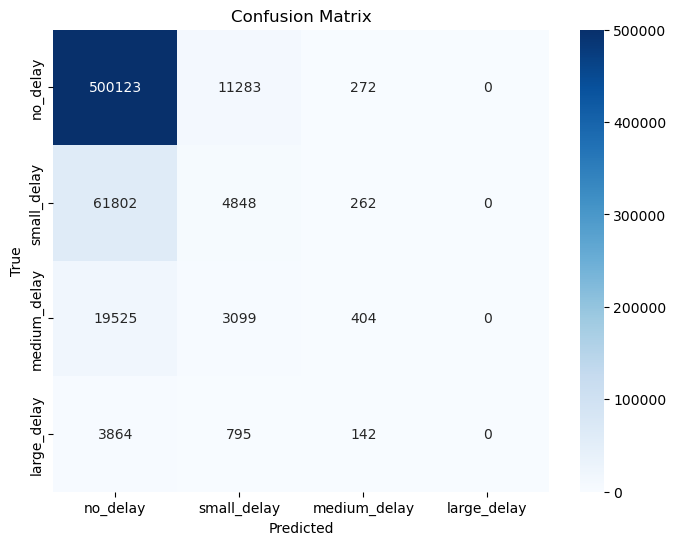

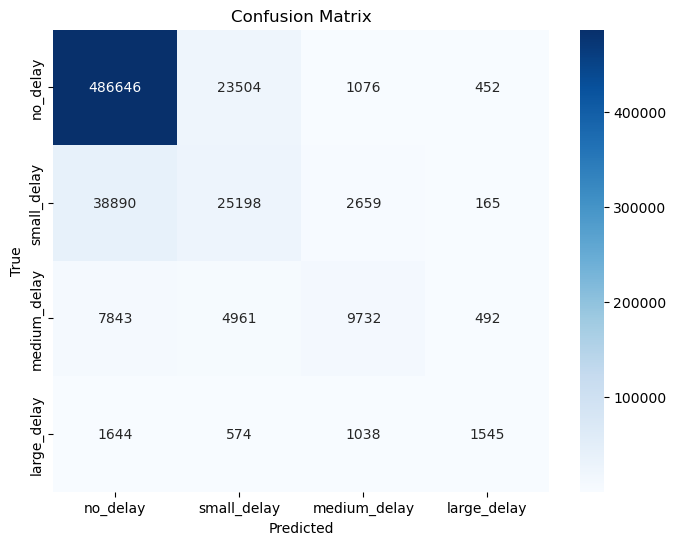

In [35]:
# plot baseline confusion matrix
plotConfusionMatrix(predictions=baseline_predictions, y_true=y_test)
plotConfusionMatrix(predictions=val_predictions, y_true=y_test)


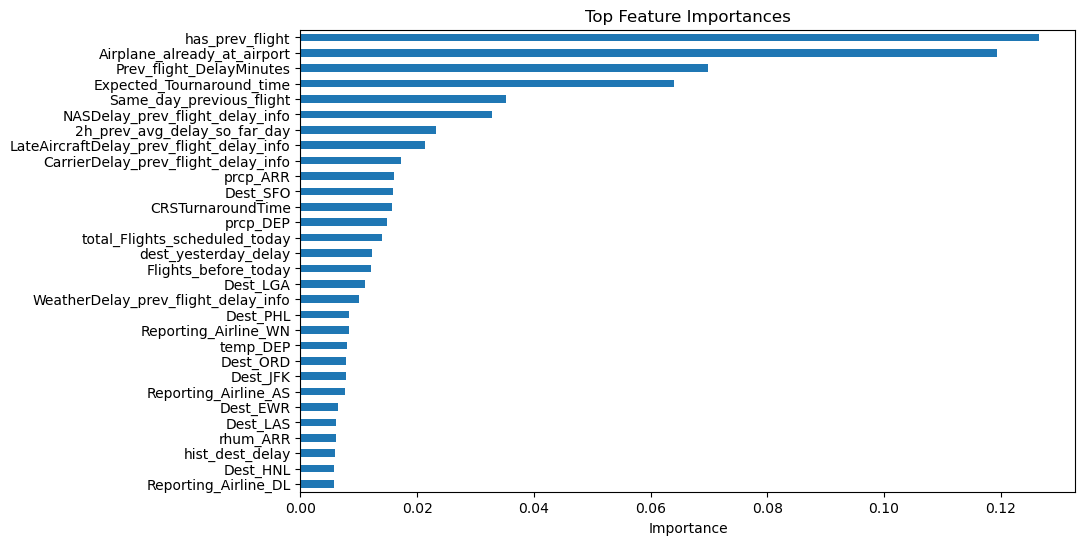

has_prev_flight                             0.126500
Airplane_already_at_airport                 0.119383
Prev_flight_DelayMinutes                    0.069829
Expected_Tournaround_time                   0.064036
Same_day_previous_flight                    0.035149
NASDelay_prev_flight_delay_info             0.032743
2h_prev_avg_delay_so_far_day                0.023146
LateAircraftDelay_prev_flight_delay_info    0.021401
CarrierDelay_prev_flight_delay_info         0.017167
prcp_ARR                                    0.016017
Dest_SFO                                    0.015838
CRSTurnaroundTime                           0.015718
prcp_DEP                                    0.014856
total_Flights_scheduled_today               0.013981
dest_yesterday_delay                        0.012323
Flights_before_today                        0.012017
Dest_LGA                                    0.011140
WeatherDelay_prev_flight_delay_info         0.010106
Dest_PHL                                    0.

In [36]:
# get the feature importances for the model and plot them
feature_importances = get_feature_importances(model, feature_names=X_train.columns)
# plot the feature importances
plot_feature_importances(feature_importances, top_n=30)
display(feature_importances.head(30))

c:\miniconda3\envs\imgP\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:11:51] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


F1-macro: 0.5400


accuracy             0.878534
balanced_accuracy    0.463827
macro_f1             0.539996
weighted_f1          0.854447
Name: xgboost_validation_metrics, dtype: float64

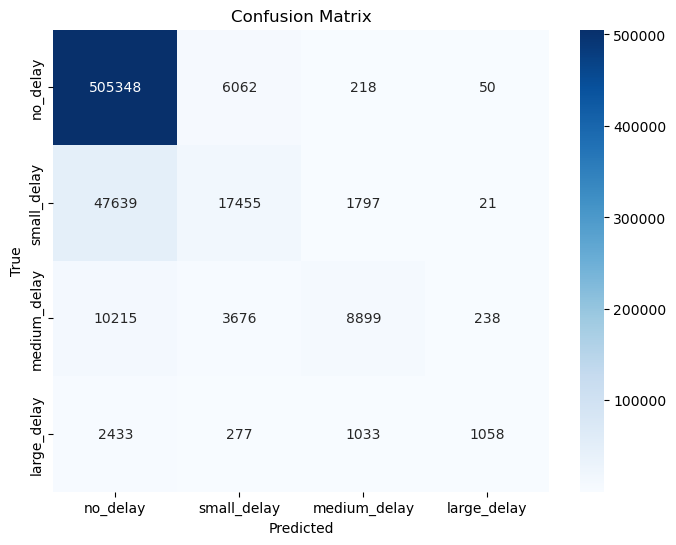

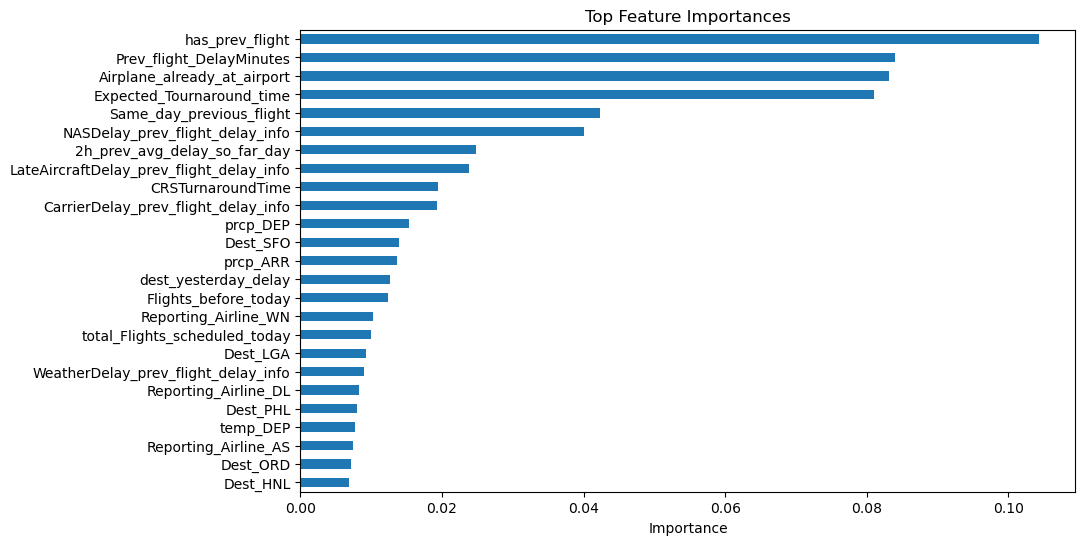

In [37]:
# without class weights
model2 = make_model(MODEL_NAME)
# fit_model_with_class_weights(model, X_train, y_train)
model2.fit(X_train, y_train)
val_metrics, val_predictions = evaluate_classifier(model2, X_test, y_test)
display(pd.Series(val_metrics, name=f'{MODEL_NAME}_validation_metrics'))
plotConfusionMatrix(predictions=val_predictions, y_true=y_test)
# get the feature importances for the model and plot them
feature_importances = get_feature_importances(model2, feature_names=X_train.columns)
# plot the feature importances
plot_feature_importances(feature_importances, top_n=25)

In [38]:
test_metrics = evaluate_classifier(model, X_test, y_test)
pd.Series(test_metrics, name=f'{MODEL_NAME}_test_metrics')

F1-macro: 0.5697


0    {'accuracy': 0.8626395281150492, 'balanced_acc...
1    [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
Name: xgboost_test_metrics, dtype: object

## 9. Final Test Evaluation

Only use the test set after choosing a model. This gives the honest final estimate for the report.


In [39]:
test_metrics = evaluate_classifier(model, X_test, y_test)
pd.Series(test_metrics, name=f'{MODEL_NAME}_test_metrics')


F1-macro: 0.5697


0    {'accuracy': 0.8626395281150492, 'balanced_acc...
1    [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
Name: xgboost_test_metrics, dtype: object

In [40]:
# Per-class report. Look especially at recall for medium_delay and large_delay.
classification_report_frame(model, X_test, y_test)


,precision,recall,f1-score,support
no_delay,0.909580,0.951079,0.929866,511678.00000
small_delay,0.464591,0.376584,0.415984,66912.00000
medium_delay,0.670941,0.422616,0.518584,23028.00000
large_delay,0.582140,0.321808,0.414487,4801.00000
accuracy,0.862640,0.862640,0.862640,0.86264
macro avg,0.656813,0.518022,0.569730,606419.00000
weighted avg,0.848825,0.862640,0.853467,606419.00000
